<a href="https://colab.research.google.com/github/melihaslan233-glitch/Water-Quality-data-/blob/main/FINALwaterdataSAMSUNG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1767]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, f1_score, roc_auc_score,
                             mean_squared_error, r2_score)
import joblib

In [1768]:
df_water = pd.read_csv('/content/drive/MyDrive/waterdata2019.csv')
df_mortality = pd.read_csv('/content/drive/MyDrive/mortalityrate2019.csv',sep=';', skiprows=5)
df_gdp = pd.read_csv('/content/drive/MyDrive/gdppercapita.csv',skiprows=4)


df_mortality_2019 = df_mortality[['Country Code', '2019']].copy()
df_gdp_2019 = df_gdp[['Country Code', '2019']].copy() # filtering for 2019

df_mortality_2019.rename(columns={'Country Code': 'ISO3', '2019': 'Mortality_Rate_2019'}, inplace=True)
df_gdp_2019.rename(columns={'Country Code': 'ISO3', '2019': 'GDP_Per_Capita_2019'}, inplace=True)

In [1769]:
df_water_wide = df_water.pivot_table(
    index=['ISO3', 'Country'],
    columns='Service level',
    values='Coverage'
).reset_index()


In [1770]:
df_merged = pd.merge(df_water_wide, df_mortality_2019, on='ISO3', how='inner')
df_total = pd.merge(df_merged, df_gdp_2019, on='ISO3', how='inner')

df_total.dropna(subset=['Mortality_Rate_2019'], inplace=True)

display(df_total.head())

,ISO3,Country,At least basic,Basic service,Limited service,Safely managed service,Surface water,Unimproved,Mortality_Rate_2019,GDP_Per_Capita_2019
0,AFG,Afghanistan,NaN,43.10,4.32,26.72,10.02,15.84,16.60,496.60
1,AGO,Angola,64.16,NaN,10.64,NaN,12.18,13.02,48.90,2493.68
2,ALB,Albania,NaN,24.09,2.22,70.67,0.00,3.03,3.20,6069.44
4,ARE,United Arab Emirates,NaN,1.37,0.00,98.63,0.00,0.00,0.80,45938.61
5,ARM,Armenia,NaN,17.03,0.00,82.43,0.45,0.09,5.80,4597.23


Feature engineering

In [1771]:
def gdp_group(gdp):
    if pd.isna(gdp):   return np.nan
    elif gdp < 1026:   return 'Low Income'
    elif gdp < 3996:   return 'Lower-Middle Income'
    elif gdp < 12376:  return 'Upper-Middle Income'
    else:              return 'High Income'
    # Safe water access: At least basic and safely managed

In [1772]:
df_total['Income_Group'] = df_total['GDP_Per_Capita_2019'].apply(gdp_group)

In [1773]:
# Binary target: High mortality = 1 if above median, 0 if below
median_mort = df_total['Mortality_Rate_2019'].median()
df_total['High_Mortality'] = (df_total['Mortality_Rate_2019'] > median_mort).astype(int)
print(f"\nMedian mortality rate: {median_mort:.2f}")
print(df_total['High_Mortality'].value_counts())


Median mortality rate: 6.10
High_Mortality
0    90
1    87
Name: count, dtype: int64


EDA

In [1774]:
cols_of_interest = ['Safely managed service', 'At least basic', 'Unimproved',
                    'Surface water', 'Mortality_Rate_2019', 'GDP_Per_Capita_2019']
summary = df_total[cols_of_interest].describe().round(2)

print(summary)

       Safely managed service  At least basic  Unimproved  Surface water  \
count                  129.00           48.00      177.00         169.00   
mean                    67.26           81.38        5.38           2.42   
std                     29.90           16.90        7.54           4.04   
min                      6.11           39.91        0.00           0.00   
25%                     44.28           68.14        0.25           0.00   
50%                     72.22           87.64        1.77           0.27   
75%                     96.61           95.19        7.42           3.23   
max                    100.00           99.97       34.48          21.22   

       Mortality_Rate_2019  GDP_Per_Capita_2019  
count               177.00               174.00  
mean                 16.84             14506.37  
std                  21.61             19906.35  
min                   0.40               234.31  
25%                   2.90              2132.79  
50%            

Correlation heatmap

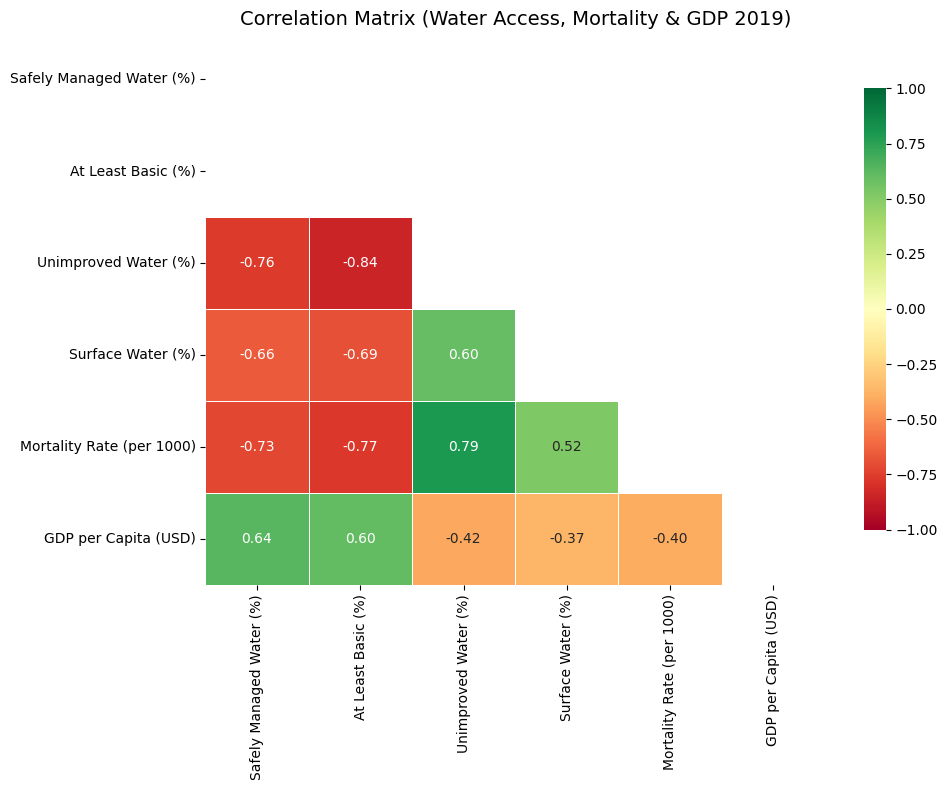

In [1775]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_data = df_total[cols_of_interest].copy()
corr_data.columns = ['Safely Managed Water (%)', 'At Least Basic (%)',
                      'Unimproved Water (%)', 'Surface Water (%)',
                      'Mortality Rate (per 1000)', 'GDP per Capita (USD)']
mask = np.triu(np.ones_like(corr_data.corr(), dtype=bool))
sns.heatmap(corr_data.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix (Water Access, Mortality & GDP 2019)', fontsize=14)
plt.tight_layout()
plt.savefig('fig1_correlation_heatmap.png', bbox_inches='tight')
plt.show()

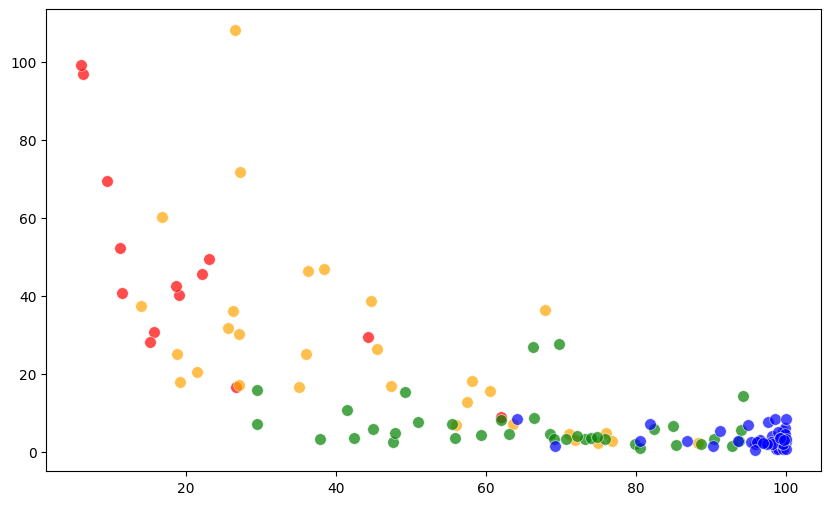

In [1776]:
fig, ax = plt.subplots(figsize=(10, 6))

palette = {
    'Low Income': 'red',
    'Lower-Middle Income': 'orange',
    'Upper-Middle Income': 'green',
    'High Income': 'blue'
}

for group, color in palette.items():
    mask = df_total['Income_Group'] == group
    ax.scatter(df_total.loc[mask, 'Safely managed service'],
               df_total.loc[mask, 'Mortality_Rate_2019'],
               c=color, label=group, alpha=0.7, edgecolors='white', linewidth=0.5, s=70)

REGRESSION


In [1778]:
x_valid = df_total[['Safely managed service', 'Mortality_Rate_2019']].dropna()
m, b, r, p, _ = stats.linregress(x_valid['Safely managed service'], x_valid['Mortality_Rate_2019'])
x_line = np.linspace(x_valid['Safely managed service'].min(), x_valid['Safely managed service'].max(), 100)
ax.plot(x_line, m * x_line + b, 'k--', linewidth=1.5, label=f'Trend (r={r:.2f}, p<0.001)')
ax.set_xlabel('Safely Managed Water Coverage (%)')
ax.set_ylabel('Child Mortality Rate (per 1,000 live births)')
ax.set_title('SDG 6 vs SDG 3: Safe Water Access & Child Mortality by Income Group (2019)', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('fig2_scatter_water_mortality.png', bbox_inches='tight')
plt.show()
print(f"Pearson r = {r:.3f}, p-value = {p:.4f}")

<Figure size 640x480 with 0 Axes>

Pearson r = -0.725, p-value = 0.0000


Mortality


/tmp/ipykernel_557/1528952636.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


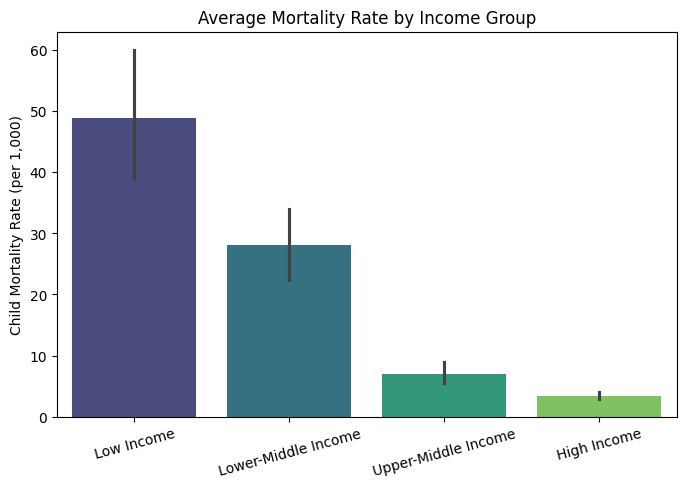

In [1779]:
plt.figure(figsize=(8, 5))
order = ['Low Income', 'Lower-Middle Income', 'Upper-Middle Income', 'High Income']

sns.barplot(
    data=df_total,
    x='Income_Group',
    y='Mortality_Rate_2019',
    order=order,
    palette='viridis'
)

plt.xticks(rotation=15)
plt.title('Average Mortality Rate by Income Group')
plt.ylabel('Child Mortality Rate (per 1,000)')
plt.xlabel('') # Hides 'Income_Group'

plt.show()

Safe water access

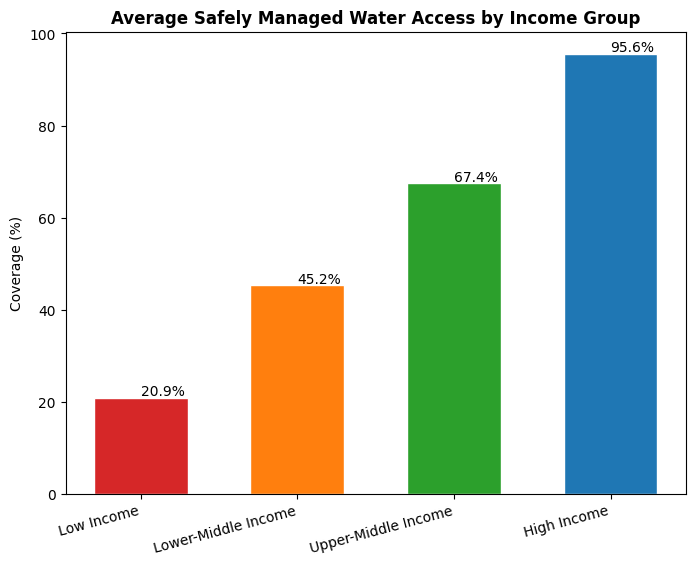

In [1780]:
plt.figure(figsize=(8, 6))

water_by_income = df_total.groupby('Income_Group')['Safely managed service'].mean().reindex(order)

plt.bar(order, water_by_income.values, color=colors, edgecolor='white', width=0.6)

plt.title('Average Safely Managed Water Access by Income Group')
plt.ylabel('Coverage (%)')

plt.xticks(ticks=range(len(order)), labels=order, rotation=15, ha='right')

for i, v in enumerate(water_by_income.values):
    if not np.isnan(v):
        plt.text(i, v + 0.5, f'{v:.1f}%',fontsize=10)

plt.show()

Distribution of service levels

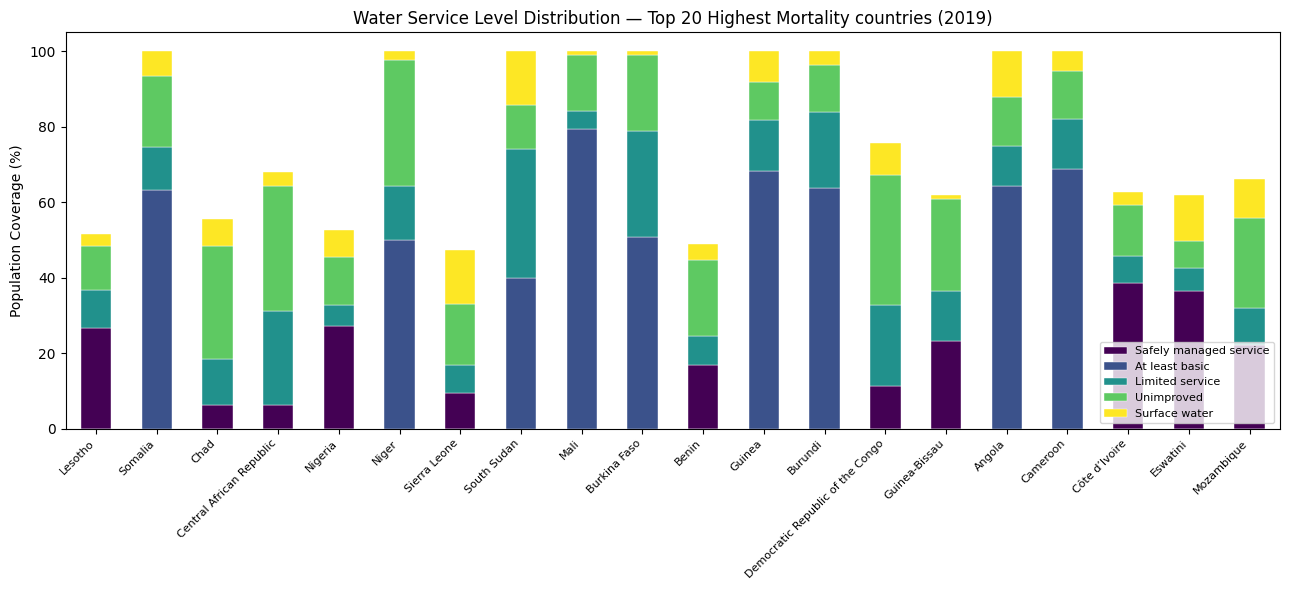

In [1781]:
top20 = df_total.nlargest(20, 'Mortality_Rate_2019')[
    ['Country', 'Safely managed service', 'At least basic',
     'Limited service', 'Unimproved', 'Surface water']
].set_index('Country').fillna(0)

fig, ax = plt.subplots(figsize=(13, 6))

top20.plot(kind='bar', stacked=True, ax=ax,
           colormap='viridis',
           edgecolor='white', linewidth=0.3)

ax.set_title('Water Service Level Distribution — Top 20 Highest Mortality countries (2019)')
ax.set_ylabel('Population Coverage (%)')
ax.set_xlabel('')
ax.legend(loc='lower right', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('fig4_stacked_bar_top20.png', bbox_inches='tight')
plt.show()

GDP VS MORTALITY

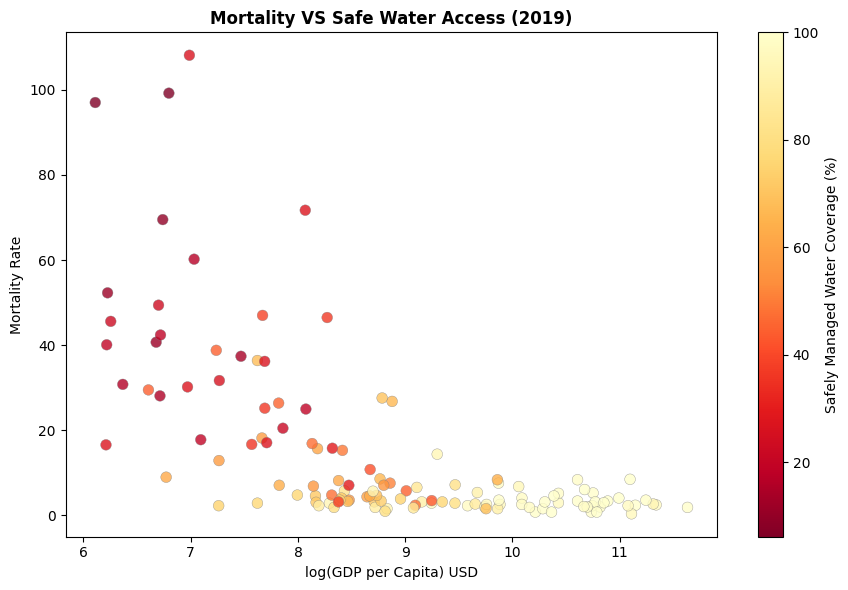

In [1782]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(np.log1p(df_total['GDP_Per_Capita_2019']),
           df_total['Mortality_Rate_2019'],
           c=df_total['Safely managed service'], cmap='YlOrRd_r',
           alpha=0.8, s=60, edgecolors='grey', linewidth=0.3)
sm = plt.cm.ScalarMappable(cmap='YlOrRd_r',
     norm=plt.Normalize(vmin=df_total['Safely managed service'].min(),
                        vmax=df_total['Safely managed service'].max()))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Safely Managed Water Coverage (%)')
ax.set_xlabel('log(GDP per Capita) USD')
ax.set_ylabel('Mortality Rate')
ax.set_title('Mortality VS Safe Water Access (2019)')
plt.tight_layout()
plt.savefig('fig5_gdp_mortality_water.png', bbox_inches='tight')
plt.show()

FEATURE PREPARATION FOR ML

In [1783]:
feature_cols = ['Safely managed service', 'At least basic', 'Basic service',
                'Limited service', 'Unimproved', 'Surface water', 'GDP_Per_Capita_2019']

df_ml = df_total.copy()

# filling missing water data with 0
water_cols = ['Safely managed service', 'At least basic', 'Basic service',
              'Limited service', 'Unimproved', 'Surface water']
df_ml[water_cols] = df_ml[water_cols].fillna(0)

# flling missing GDP with the median of the column
df_ml['GDP_Per_Capita_2019'] = df_ml['GDP_Per_Capita_2019'].fillna(df_ml['GDP_Per_Capita_2019'].median())

# dropping rows only if the target is missing
df_ml = df_ml.dropna(subset=['High_Mortality'])

print(f"ML-ready rows: {len(df_ml)}")

X = df_ml[feature_cols]
y_class = df_ml['High_Mortality']

ML-ready rows: 177


Model refinement

Train test split


In [1784]:
if len(X) == 0:
    print("CRITICAL ERROR: X is empty! Check your previous filtering steps.")
else:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_class, test_size=0.2, random_state=42, stratify=y_class
    )

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)

    print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 141, Test size: 36


In [1785]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42, stratify=y_class
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 141, Test size: 36


Baseline models

In [1786]:
base_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "KNN":                 KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42)
}

baseline_results = {}
for name, model in base_models.items():
    model.fit(X_train_sc, y_train)
    preds= model.predict(X_test_sc)
    acc= accuracy_score(y_test, preds)
    f1= f1_score(y_test, preds, average='weighted')
    baseline_results[name] = {'Accuracy': acc, 'F1': f1}
    print(f"  {name:25s}  Acc={acc:.4f}  F1={f1:.4f}")

  Logistic Regression        Acc=0.7500  F1=0.7483
  Random Forest              Acc=0.8333  F1=0.8333
  Decision Tree              Acc=0.7500  F1=0.7498
  KNN                        Acc=0.7222  F1=0.7214
  Gradient Boosting          Acc=0.7222  F1=0.7222


K Fold Validation

In [1787]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}
for name, model in base_models.items():
    scores = cross_val_score(model, X_train_sc, y_train, cv=skf, scoring='accuracy')
    cv_results[name] = scores
    print(f"  {name:25s}  Mean={scores.mean():.4f}  Std={scores.std():.4f}")

  Logistic Regression        Mean=0.8443  Std=0.0468
  Random Forest              Mean=0.8512  Std=0.0409
  Decision Tree              Mean=0.8015  Std=0.0360
  KNN                        Mean=0.8441  Std=0.0161
  Gradient Boosting          Mean=0.8089  Std=0.0465


Feature Selection (RFE Random Forest

In [1788]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(estimator=rf_base, n_features_to_select=5)
rfe.fit(X_train_sc, y_train)
selected_features = [feature_cols[i] for i in range(len(feature_cols)) if rfe.support_[i]]
print(f"  Selected features: {selected_features}")

  Selected features: ['Safely managed service', 'Limited service', 'Unimproved', 'Surface water', 'GDP_Per_Capita_2019']


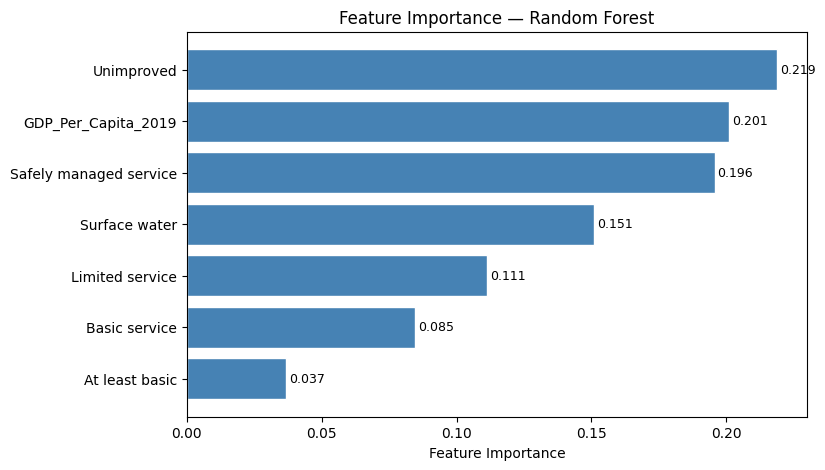

In [1789]:
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X_train_sc, y_train)
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_temp.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance')
ax.set_title('Feature Importance — Random Forest')
for bar, val in zip(bars, importance_df['Importance']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.show()

X

In [1790]:
X_sel = df_ml[selected_features]
X_train_sel, X_test_sel, _, _ = train_test_split(
    X_sel, y_class, test_size=0.2, random_state=42, stratify=y_class
)
scaler_sel = StandardScaler()
X_train_sel_sc = scaler_sel.fit_transform(X_train_sel)
X_test_sel_sc  = scaler_sel.transform(X_test_sel)

Hyperparameter Tuning

GridSearchCV

In [1791]:
# Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [None, 5, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid, cv=skf, scoring='accuracy', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train_sel_sc, y_train)
print(f"  RF best params:  {rf_grid.best_params_}")
print(f"  RF best CV acc:  {rf_grid.best_score_:.4f}")
best_rf = rf_grid.best_estimator_

# Gradient Boosting
gb_param_grid = {
    'n_estimators':   [50, 100, 200],
    'learning_rate':  [0.05, 0.1, 0.2],
    'max_depth':      [3, 5, 7],
}
gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_param_grid, cv=skf, scoring='accuracy', n_jobs=-1, verbose=0
)
gb_grid.fit(X_train_sel_sc, y_train)
print(f"  GB best params:  {gb_grid.best_params_}")
print(f"  GB best CV acc:  {gb_grid.best_score_:.4f}")
best_gb = gb_grid.best_estimator_

# Logistic Regression
lr_param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['lbfgs', 'liblinear']}
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    lr_param_grid, cv=skf, scoring='accuracy', n_jobs=-1
)
lr_grid.fit(X_train_sel_sc, y_train)
print(f"  LR best params:  {lr_grid.best_params_}")
print(f"  LR best CV acc:  {lr_grid.best_score_:.4f}")
best_lr = lr_grid.best_estimator_

#Tuned model scores
print(f"  Random Forest     CV acc: {rf_grid.best_score_:.4f}")
print(f"  Gradient Boosting CV acc: {gb_grid.best_score_:.4f}")
print(f"  Logistic Regr.    CV acc: {lr_grid.best_score_:.4f}")


print("CV vs Test Comparison")
for name, cv_score, test_key in [
    ("Random Forest",     rf_grid.best_score_, "Random Forest (Tuned)"),
    ("Gradient Boosting", gb_grid.best_score_, "Gradient Boosting (Tuned)"),
    ("Logistic Regr.",    lr_grid.best_score_, "Logistic Regression (Tuned)"),
]:
    test_acc = test_results[test_key]['Accuracy']
    gap = abs(cv_score - test_acc)
    overfit = "possible overfit" if gap > 0.05 else "stable"
    print(f"  {name:22s}  CV={cv_score:.4f}  Test={test_acc:.4f}  Gap={gap:.4f}  {overfit}")

  RF best params:  {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 50}
  RF best CV acc:  0.8372
  GB best params:  {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
  GB best CV acc:  0.8300
  LR best params:  {'C': 0.01, 'solver': 'lbfgs'}
  LR best CV acc:  0.8308
  Random Forest     CV acc: 0.8372
  Gradient Boosting CV acc: 0.8300
  Logistic Regr.    CV acc: 0.8308
CV vs Test Comparison
  Random Forest           CV=0.8372  Test=0.8333  Gap=0.0039  stable
  Gradient Boosting       CV=0.8300  Test=0.7500  Gap=0.0800  possible overfit
  Logistic Regr.          CV=0.8308  Test=0.7778  Gap=0.0530  possible overfit


Evaluation

In [1792]:
tuned_models = {
    "Random Forest (Tuned)":       best_rf,
    "Gradient Boosting (Tuned)":   best_gb,
    "Logistic Regression (Tuned)": best_lr
}

In [1793]:
test_results = {}

for name, model in tuned_models.items():
    preds  = model.predict(X_test_sel_sc)
    acc    = accuracy_score(y_test, preds)
    f1     = f1_score(y_test, preds, average='weighted')
    try:
        auc_score = roc_auc_score(y_test, model.predict_proba(X_test_sel_sc)[:, 1])
    except Exception:
        auc_score = np.nan
    test_results[name] = {'Accuracy': acc, 'F1': f1, 'AUC': auc_score}
    print(f"\n  {name}")
    print(classification_report(y_test, preds, target_names=["Low Mortality", "High Mortality"]))


  Random Forest (Tuned)
                precision    recall  f1-score   support

 Low Mortality       0.80      0.89      0.84        18
High Mortality       0.88      0.78      0.82        18

      accuracy                           0.83        36
     macro avg       0.84      0.83      0.83        36
  weighted avg       0.84      0.83      0.83        36


  Gradient Boosting (Tuned)
                precision    recall  f1-score   support

 Low Mortality       0.74      0.78      0.76        18
High Mortality       0.76      0.72      0.74        18

      accuracy                           0.75        36
     macro avg       0.75      0.75      0.75        36
  weighted avg       0.75      0.75      0.75        36


  Logistic Regression (Tuned)
                precision    recall  f1-score   support

 Low Mortality       0.73      0.89      0.80        18
High Mortality       0.86      0.67      0.75        18

      accuracy                           0.78        36
     macro 

In [1794]:
tuned_models = {
    "Random Forest (Tuned)":       best_rf,
    "Gradient Boosting (Tuned)":   best_gb,
    "Logistic Regression (Tuned)": best_lr
}

test_results = {}

for name, model in tuned_models.items():
    preds  = model.predict(X_test_sel_sc)
    acc    = accuracy_score(y_test, preds)
    f1     = f1_score(y_test, preds, average='weighted')
    try:
        auc_score = roc_auc_score(y_test, model.predict_proba(X_test_sel_sc)[:, 1])
    except Exception:
        auc_score = np.nan
    test_results[name] = {'Accuracy': acc, 'F1': f1, 'AUC': auc_score}
    print(f"\n  {name}")
    print(classification_report(y_test, preds, target_names=["Low Mortality", "High Mortality"]))


  Random Forest (Tuned)
                precision    recall  f1-score   support

 Low Mortality       0.80      0.89      0.84        18
High Mortality       0.88      0.78      0.82        18

      accuracy                           0.83        36
     macro avg       0.84      0.83      0.83        36
  weighted avg       0.84      0.83      0.83        36


  Gradient Boosting (Tuned)
                precision    recall  f1-score   support

 Low Mortality       0.74      0.78      0.76        18
High Mortality       0.76      0.72      0.74        18

      accuracy                           0.75        36
     macro avg       0.75      0.75      0.75        36
  weighted avg       0.75      0.75      0.75        36


  Logistic Regression (Tuned)
                precision    recall  f1-score   support

 Low Mortality       0.73      0.89      0.80        18
High Mortality       0.86      0.67      0.75        18

      accuracy                           0.78        36
     macro 

Before &after refinement

Before vs After Refinement
              Model  Baseline Acc  Tuned Acc  Baseline F1  Tuned F1  AUC
Logistic Regression          0.75       0.78         0.75      0.78 0.86
      Random Forest          0.83       0.83         0.83      0.83 0.88
  Gradient Boosting          0.72       0.75         0.72      0.75 0.83


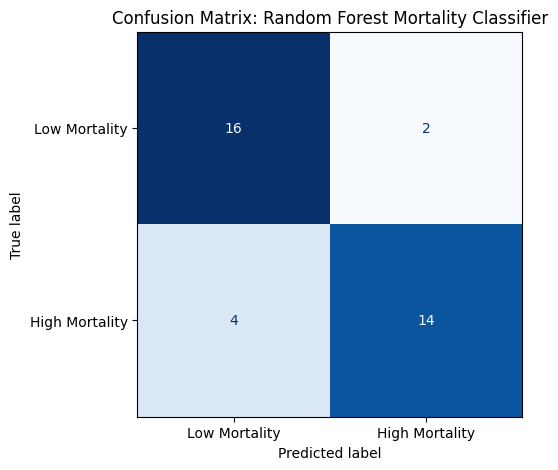

In [1795]:
comparison_data = []
for name in ['Logistic Regression', 'Random Forest', 'Gradient Boosting']:
    base_key   = name
    tuned_key  = f"{name} (Tuned)"
    if base_key in baseline_results and tuned_key in test_results:
        comparison_data.append({
            'Model': name,
            'Baseline Acc': baseline_results[base_key]['Accuracy'],
            'Tuned Acc':    test_results[tuned_key]['Accuracy'],
            'Baseline F1':  baseline_results[base_key]['F1'],
            'Tuned F1':     test_results[tuned_key]['F1'],
            'AUC':          test_results[tuned_key]['AUC']
        })

comparison_df = pd.DataFrame(comparison_data)
print("Before vs After Refinement")
print(comparison_df.round(4).to_string(index=False))

# Confusion Matrix
rf_preds = best_rf.predict(X_test_sel_sc)
cm = confusion_matrix(y_test, rf_preds)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Low Mortality", "High Mortality"])
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title("Confusion Matrix: Random Forest Mortality Classifier")

plt.show()

Overfitting Analysis

In [1796]:
print("Overfitting Analysis")
models_check = {
    "Logistic Regression": (0.8443, 0.78),
    "Random Forest":       (0.8512, 0.83),
    "Decision Tree":       (0.8015, 0.75),
    "KNN":                 (0.8441, 0.72),
    "Gradient Boosting":   (0.8089, 0.72),
}
for name, (cv, test) in models_check.items():
    gap = cv - test
    status = "overfitting" if gap > 0.05 else "generalises well"
    print(f"  {name:25s}  CV={cv:.4f}  Test={test:.4f}  Gap={gap:.4f}  {status}")

Overfitting Analysis
  Logistic Regression        CV=0.8443  Test=0.7800  Gap=0.0643  overfitting
  Random Forest              CV=0.8512  Test=0.8300  Gap=0.0212  generalises well
  Decision Tree              CV=0.8015  Test=0.7500  Gap=0.0515  overfitting
  KNN                        CV=0.8441  Test=0.7200  Gap=0.1241  overfitting
  Gradient Boosting          CV=0.8089  Test=0.7200  Gap=0.0889  overfitting


ROC curve

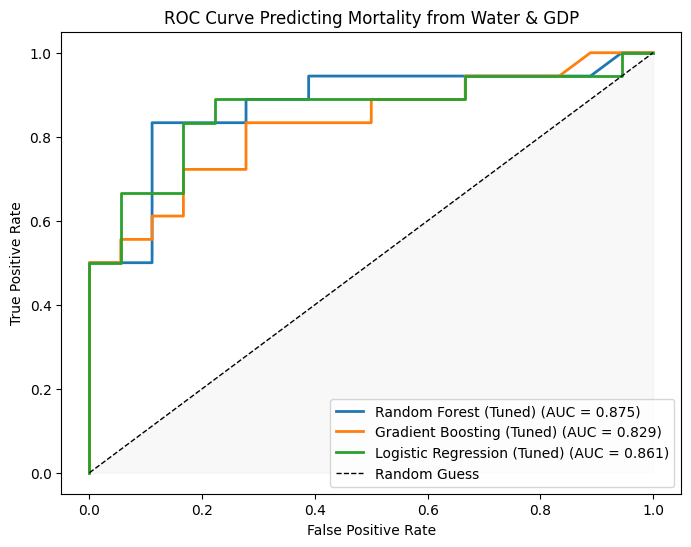

In [1797]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, model in tuned_models.items():
    probs = model.predict_proba(X_test_sel_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)

    ax.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random Guess', linewidth=1)
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Predicting Mortality from Water & GDP')
ax.legend(loc='lower right')

plt.show()

CV score comparison chart

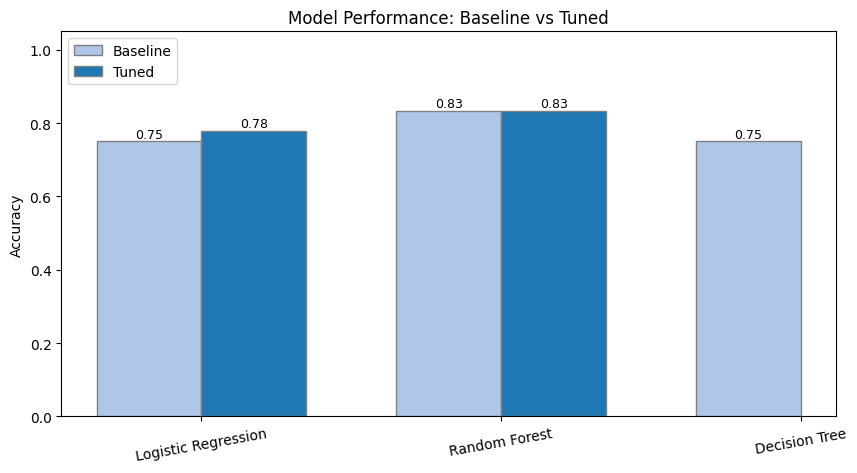

In [1798]:
fig, ax = plt.subplots(figsize=(10, 5))
models_to_compare = list(baseline_results.keys())[:3]  # top 3
x = np.arange(len(models_to_compare))
w = 0.35
before_acc = [baseline_results[m]['Accuracy'] for m in models_to_compare]
after_acc  = [test_results.get(f'{m} (Tuned)', {}).get('Accuracy', np.nan) for m in models_to_compare]
bars1 = ax.bar(x - w/2, before_acc, w, label='Baseline', color='#aec7e8', edgecolor='grey')
bars2 = ax.bar(x + w/2, after_acc,  w, label='Tuned',    color='#1f77b4', edgecolor='grey')
ax.set_xticks(x)
ax.set_xticklabels(models_to_compare, rotation=10)
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1.05)
ax.set_title('Model Performance: Baseline vs Tuned')
ax.legend()
for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01, f'{bar.get_height():.2f}', ha='center', fontsize=9)

plt.show()

Regression: Predicting actual mortality rate if Mortality Rate is target

  RMSE: 13.78  |  R²: 0.5891


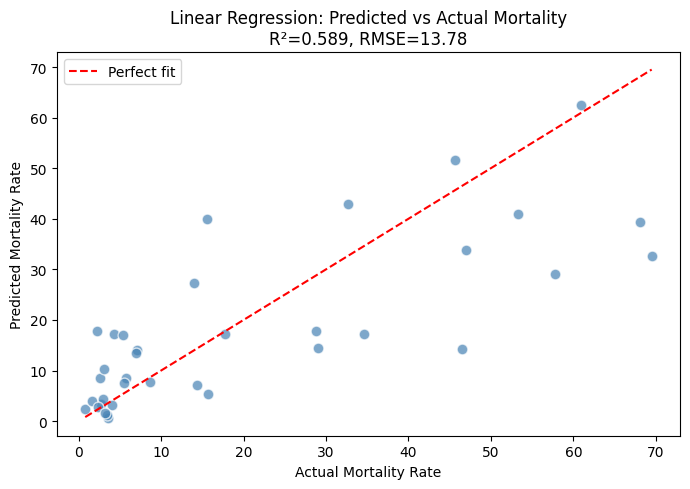

In [1799]:
y_reg = df_ml['Mortality_Rate_2019']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_sel, y_reg, test_size=0.2, random_state=42
)

scaler_reg = StandardScaler()
X_reg_train_sc = scaler_reg.fit_transform(X_reg_train)
X_reg_test_sc  = scaler_reg.transform(X_reg_test)

lr_reg = LinearRegression()
lr_reg.fit(X_reg_train_sc, y_reg_train)
y_pred_reg = lr_reg.predict(X_reg_test_sc)

rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
r2   = r2_score(y_reg_test, y_pred_reg)
print(f"  RMSE: {rmse:.2f}  |  R²: {r2:.4f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_reg_test, y_pred_reg, alpha=0.7, color='steelblue', edgecolors='white', s=60)
ax.plot([y_reg_test.min(), y_reg_test.max()], [y_reg_test.min(), y_reg_test.max()],
        'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual Mortality Rate')
ax.set_ylabel('Predicted Mortality Rate')
ax.set_title(f'Linear Regression: Predicted vs Actual Mortality\nR²={r2:.3f}, RMSE={rmse:.2f}')
ax.legend()
plt.tight_layout()
plt.savefig('fig10_regression_actual_vs_predicted.png', bbox_inches='tight')
plt.show()

In [1800]:
from sklearn.ensemble import RandomForestRegressor

# RF Regressor(comparing with linear Regression)
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_reg_train_sc, y_reg_train)
y_pred_rf_reg = rf_reg.predict(X_reg_test_sc)

rmse_rf = np.sqrt(mean_squared_error(y_reg_test, y_pred_rf_reg))
r2_rf   = r2_score(y_reg_test, y_pred_rf_reg)

print(f"  Linear Regression  RMSE: {rmse:.2f}  R²: {r2:.4f}")
print(f"  RF Regressor       RMSE: {rmse_rf:.2f}  R²: {r2_rf:.4f}")
print(f"  R² improvement: +{r2_rf - r2:.4f}")

  Linear Regression  RMSE: 13.78  R²: 0.5891
  RF Regressor       RMSE: 12.84  R²: 0.6431
  R² improvement: +0.0540


MODEL SERIALISATION

In [1801]:
# Saving the best model and scaler using joblib
joblib.dump(best_rf,    'best_rf_mortality_classifier.joblib')
joblib.dump(scaler_sel, 'scaler_water_sdg.joblib')
print("  Model saved: best_rf_mortality_classifier.joblib")
print("  Scaler saved: scaler_water_sdg.joblib")


loaded_model  = joblib.load('best_rf_mortality_classifier.joblib')
loaded_scaler = joblib.load('scaler_water_sdg.joblib')

#predicting for a new country's water/GDP profile
example_country = pd.DataFrame([{
    'Safely managed service': 45.0,
    'At least basic':         60.0,
    'Limited service':        10.0,
    'Unimproved':             20.0,
    'Surface water':          5.0,
    'GDP_Per_Capita_2019':    1500.0
}])[selected_features]  # keep only RFE selected features

example_scaled = loaded_scaler.transform(example_country)
prediction     = loaded_model.predict(example_scaled)
probability    = loaded_model.predict_proba(example_scaled)
print(f"\n  Example country prediction: {'High Mortality' if prediction[0] == 1 else 'Low Mortality'}")
print(f"  Probability [Low, High]: {probability[0].round(3)}")

  Model saved: best_rf_mortality_classifier.joblib
  Scaler saved: scaler_water_sdg.joblib

  Example country prediction: High Mortality
  Probability [Low, High]: [0. 1.]


DEPLOYMENT

In [1802]:
api_code = '''
import joblib
import numpy as np
from fastapi import FastAPI, Header, HTTPException
from pydantic import BaseModel, Field
import datetime

app = FastAPI(title="Water & Mortality Predictor")

# Load artifacts
model  = joblib.load("best_rf_mortality_classifier.joblib")
scaler = joblib.load("scaler_water_sdg.joblib")

API_KEY = "water-ml-2025"

class WaterInput(BaseModel):
    safely_managed: float = Field(..., ge=0, le=100)
    limited_service: float = Field(..., ge=0, le=100)
    unimproved: float = Field(..., ge=0, le=100)
    surface_water: float = Field(..., ge=0, le=100)
    gdp_per_capita: float = Field(..., ge=0)

@app.get("/health")
def health():
    return {"status": "ok", "timestamp": str(datetime.datetime.now())}

@app.post("/predict")
def predict(data: WaterInput, x_api_key: str = Header(...)):
        raise HTTPException(status_code=401, detail="Invalid API key")

    features = np.array([[
        data.safely_managed,
        data.limited_service,
        data.unimproved,
        data.surface_water,
        data.gdp_per_capita
    ]])

    scaled = scaler.transform(features)
    prediction = int(model.predict(scaled)[0])
    probability = float(model.predict_proba(scaled)[0][prediction])
    label = "High Mortality" if prediction == 1 else "Low Mortality"

    return {
        "prediction": label,
        "confidence": round(probability, 3),
        "timestamp": str(datetime.datetime.now())
    }

@app.get("/classes")
def classes():
    return {
        "0": "Low Mortality — below median (6.10 per 1,000 live births)",
        "1": "High Mortality — above median (6.10 per 1,000 live births)"
    }


with open('api.py', 'w') as f:
    f.write(api_code)

print("api.py saved. Run with: uvicorn api:app --host 0.0.0.0 --port 8000")

'''



SUMMARY

In [1803]:
summary_rows = []
for name, res in test_results.items():
    summary_rows.append({
        'Model': name, 'Accuracy': res['Accuracy'],
        'F1 Score': res['F1'], 'AUC-ROC': res['AUC']
    })
summary_df = pd.DataFrame(summary_rows).sort_values('AUC-ROC', ascending=False)
print(summary_df.round(4).to_string(index=False))

print("Target: Predict countries with high mortality risk")
print("Features: Safely managed, basic, and unimproved water access")
print("Feature: GDP per capita as economic inequality proxy")

                      Model  Accuracy  F1 Score  AUC-ROC
      Random Forest (Tuned)      0.83      0.83     0.88
Logistic Regression (Tuned)      0.78      0.78     0.86
  Gradient Boosting (Tuned)      0.75      0.75     0.83
Target: Predict countries with high mortality risk
Features: Safely managed, basic, and unimproved water access
Feature: GDP per capita as economic inequality proxy
